# Earnings Call Sentiment Analysis — Full Pipeline

**Course:** M.Sc. NLP — HIT  
**Track:** 3 — Data-Driven  
**Topic:** Comparative Sentiment Analysis of Earnings Calls (Prepared Remarks vs. Q&A)

---

## AI Usage Disclosure
This project used Claude Code (Anthropic) to assist with code scaffolding, module design, and documentation.  
All model logic, regex patterns, evaluation design, and interpretation were reviewed and verified by the student.  
See `AI_USAGE.md` for the full disclosure log.

---

## Research Question
**Which combination of (segment × model) best predicts the direction of market-adjusted stock returns (up/down)?**
- Segment: Prepared Remarks vs. Q&A section of earnings calls
- Model: Loughran-McDonald Lexicon (baseline) vs. FinBERT (advanced transformer)
- **Task: binary up/down classification** relative to S&P 500, per the project proposal

---

## How to Run
1. Ensure the `.venv` kernel is selected in VS Code Jupyter
2. Run `python main.py --mode scrape` first to populate `data/raw/transcripts/`
3. Execute cells top-to-bottom — each cell is idempotent

In [ ]:
# Setup — imports, seeds, logging
import logging
import os
import random
import warnings
from pathlib import Path

# Switch the working directory to the project root so all relative
_HERE = Path.cwd().resolve()
if _HERE.name == 'notebooks':
    os.chdir(_HERE.parent)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(levelname)s | %(message)s')

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.float_format', '{:.4f}'.format)

print(f'Python environment ready. PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')

Python environment ready. PyTorch: 2.11.0+cpu
CUDA available: False


## 1. Data Verification
Load the URL manifest and verify scraped transcript coverage.

Manifest entries : 124
Scraped JSON files: 124

Sector distribution:
sector
Technology                43
Financials                21
Communication Services    19
Consumer Staples          11
Consumer Discretionary    10
Energy                     7
Industrials                7
Healthcare                 6


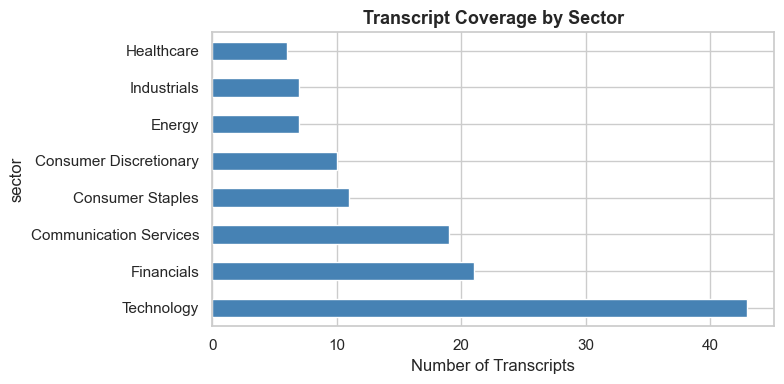

In [ ]:
# Manifest and transcript inventory
import sys
sys.path.insert(0, str(Path('..').resolve()))

from src.scrapers.url_builder import load_manifest
from src.utils.storage import list_transcripts

manifest = pd.DataFrame(load_manifest(Path('data/raw/url_manifest.csv')))
transcript_files = list_transcripts(Path('data/raw/transcripts'))

print(f'Manifest entries : {len(manifest)}')
print(f'Scraped JSON files: {len(transcript_files)}')
print()

# Sector distribution
sector_counts = manifest['sector'].value_counts()
print('Sector distribution:')
print(sector_counts.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
sector_counts.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Transcript Coverage by Sector', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Transcripts')
plt.tight_layout()
plt.show()

## 2. Preprocessing Demo
Show segment splitting on one transcript and inspect token distribution.

In [ ]:
# Preprocessing demo on a single transcript
import json
from src.processing.segmenter import split_transcript, validate_split
from src.processing.cleaner import clean_text
from src.processing.tokenizer import tokenize_for_lexicon

if transcript_files:
    sample_path = transcript_files[0]
    with open(sample_path, encoding='utf-8') as f:
        rec = json.load(f)

    segments = split_transcript(rec['raw_text'], rec['ticker'], rec['date'])

    print(f'Ticker   : {segments.ticker}')
    print(f'Date     : {segments.date}')
    print(f'Method   : {segments.split_method}')
    print(f'Successful: {segments.split_successful}')
    print(f'Prepared  : {len(segments.prepared_remarks):,} chars')
    print(f'Q&A       : {len(segments.qa_section):,} chars')
    print()
    print('--- Prepared Remarks (first 500 chars) ---')
    print(clean_text(segments.prepared_remarks)[:500])
    print()
    print('--- Q&A Section (first 500 chars) ---')
    print(clean_text(segments.qa_section)[:500])
else:
    print('No transcripts found. Run: python main.py --mode scrape')

Ticker   : AAPL
Date     : 2022-01-27
Method   : regex_fallback
Successful: True
Prepared  : 19,672 chars
Q&A       : 29,380 chars

--- Prepared Remarks (first 500 chars) ---
Apple ( AAPL 0.01% ) Q1 2022 Earnings Call Jan 27, 2022 , 5:00 p.m. ET
Operator
Good day, and welcome to the Apple Q1 FY 2022 earnings conference call. Today's call is being recorded. At this time, for opening remarks and introductions, I would like to turn the call over to Tejas Gala, director of investor relations and corporate finance. Please go ahead.
Tejas Gala -- Director, Investor Relations, and Corporate Finance
Thank you. Good afternoon and thank you for joining us. Speaking first today

--- Q&A Section (first 500 chars) ---
Operator
Absolutely. We'll take our first question from Katy Huberty with Morgan Stanley. Katy, please check your mute function, we weren't able to hear you. Hearing no response, we'll take our next question from Wamsi Mohan with Bank of America.
Wamsi Mohan -- Bank of America Merrill

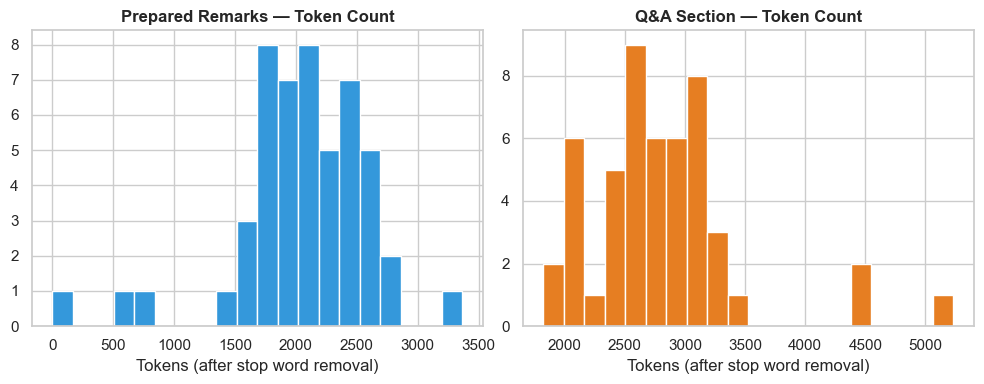

       pr_tokens  qa_tokens
count    50.0000    50.0000
mean   2044.9000  2806.5000
std     560.7000   635.0000
min       0.0000  1822.0000
25%    1823.8000  2432.8000
50%    2095.5000  2731.0000
75%    2448.8000  3059.2000
max    3367.0000  5234.0000


In [ ]:
# Token count distribution across all transcripts
from src.utils.storage import load_transcript

if transcript_files:
    token_counts = []
    for path in transcript_files[:50]:  # sample first 50 for speed
        rec = load_transcript(path)
        segs = split_transcript(rec['raw_text'], rec['ticker'], rec['date'])
        pr_tokens = tokenize_for_lexicon(segs.prepared_remarks)
        qa_tokens = tokenize_for_lexicon(segs.qa_section)
        token_counts.append({'ticker': rec['ticker'], 'date': rec['date'],
                              'pr_tokens': len(pr_tokens), 'qa_tokens': len(qa_tokens)})

    tc_df = pd.DataFrame(token_counts)
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].hist(tc_df['pr_tokens'], bins=20, color='#3498db', edgecolor='white')
    axes[0].set_title('Prepared Remarks — Token Count', fontweight='bold')
    axes[0].set_xlabel('Tokens (after stop word removal)')
    axes[1].hist(tc_df['qa_tokens'], bins=20, color='#e67e22', edgecolor='white')
    axes[1].set_title('Q&A Section — Token Count', fontweight='bold')
    axes[1].set_xlabel('Tokens (after stop word removal)')
    plt.tight_layout()
    plt.show()
    print(tc_df[['pr_tokens', 'qa_tokens']].describe().round(1))

## 3. Load Preprocessed Data
Load `segments.parquet` (produced by the preprocessing pipeline).

In [ ]:
# Load segments.parquet
segments_path = Path('data/processed/segments.parquet')

if segments_path.exists():
    df = pd.read_parquet(segments_path)
    print(f'Segments loaded: {len(df)} rows')
    print(f'Successful splits: {df["split_successful"].sum()} / {len(df)}')
    print()
    display(df[['ticker', 'date', 'split_method', 'label_1d']].head(10))
else:
    print('segments.parquet not found.')
    print('Running preprocessing pipeline...')
    from src.processing.pipeline import run_preprocessing
    df = run_preprocessing(
        raw_dir=Path('data/raw/transcripts'),
        output_path=segments_path,
    )
    print(f'Preprocessing complete: {len(df)} rows')

Segments loaded: 123 rows
Successful splits: 110 / 123



,ticker,date,split_method,label_1d
0,AAPL,2022-01-27,regex_fallback,up
1,AAPL,2022-04-28,regex_fallback,up
2,AAPL,2022-07-28,regex_fallback,up
3,AAPL,2022-10-27,regex_fallback,up
4,AAPL,2023-02-02,regex_fallback,up
5,AMZN,2023-02-02,regex_fallback,down
6,AMZN,2023-04-27,regex_fallback,down
7,AMZN,2023-08-03,regex_fallback,up
8,AMZN,2023-10-26,regex_fallback,up
9,BA,2022-01-26,regex_fallback,down


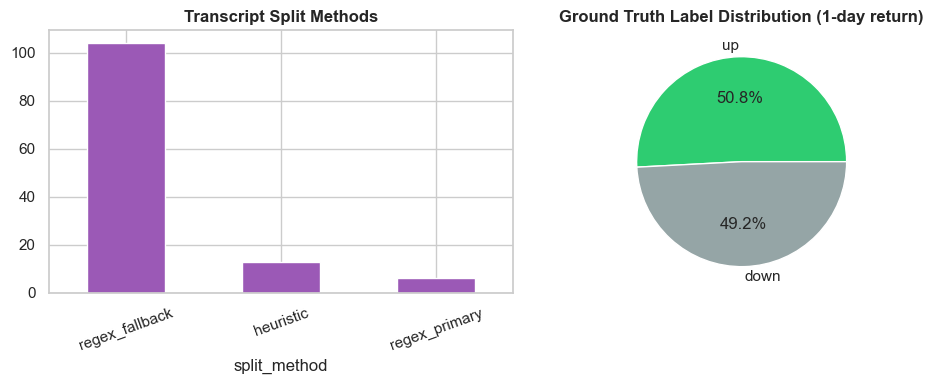

In [ ]:
# Split method and label distribution
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

df['split_method'].value_counts().plot(kind='bar', ax=axes[0], color='#9b59b6', edgecolor='white')
axes[0].set_title('Transcript Split Methods', fontweight='bold')
axes[0].tick_params(axis='x', rotation=20)

label_counts = df['label_1d'].value_counts()
axes[1].pie(label_counts, labels=label_counts.index, autopct='%1.1f%%',
            colors=['#2ecc71', '#95a5a6', '#e74c3c'])
axes[1].set_title('Ground Truth Label Distribution (1-day return)', fontweight='bold')

plt.tight_layout()
plt.show()

## 4. LM Lexicon Scoring
Score both segments using the Loughran-McDonald financial sentiment dictionary.

In [ ]:
# LM Lexicon scoring
from src.models.lm_lexicon import score_dataframe as lm_score

df = lm_score(df, token_col='prepared_tokens', prefix='pr_lm')
df = lm_score(df, token_col='qa_tokens', prefix='qa_lm')

print('LM scoring complete.')
print('Prepared Remarks labels:')
print(df['pr_lm_label'].value_counts())
print()
print('Q&A labels:')
print(df['qa_lm_label'].value_counts())

INFO | LM dictionary loaded: {'positive': 354, 'negative': 2355, 'uncertainty': 297, 'litigious': 905, 'constraining': 184}


LM scoring complete.
Prepared Remarks labels:
pr_lm_label
up      115
down      8
Name: count, dtype: int64

Q&A labels:
qa_lm_label
up      102
down     21
Name: count, dtype: int64


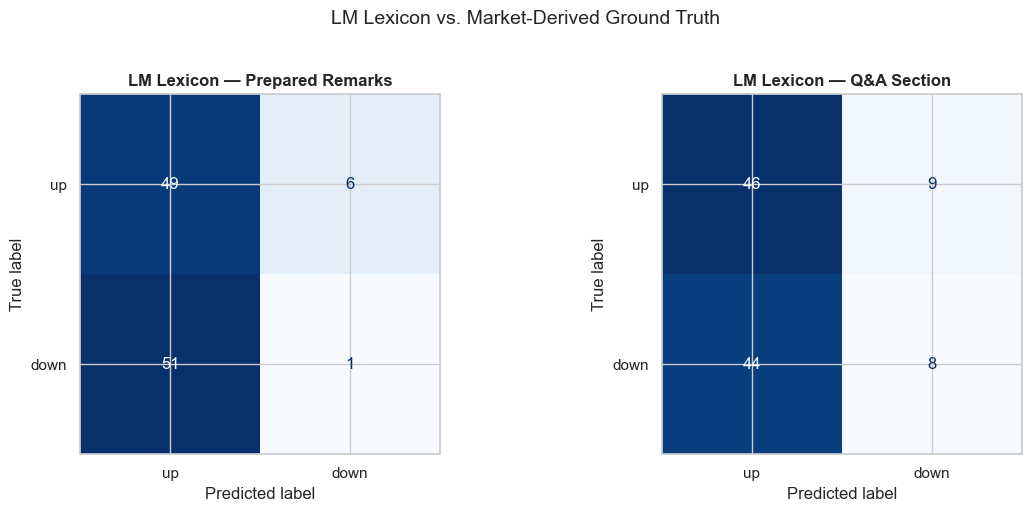

In [ ]:
# LM Lexicon confusion matrix vs. ground truth
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

eval_df = df[df['split_successful']].dropna(subset=['label_1d', 'pr_lm_label'])
labels = ['up', 'down']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, pred_col, title in [
    (axes[0], 'pr_lm_label', 'LM Lexicon — Prepared Remarks'),
    (axes[1], 'qa_lm_label', 'LM Lexicon — Q&A Section'),
]:
    cm = confusion_matrix(eval_df['label_1d'], eval_df[pred_col], labels=labels)
    disp = ConfusionMatrixDisplay(cm, display_labels=labels)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=12, fontweight='bold')

plt.suptitle('LM Lexicon vs. Market-Derived Ground Truth', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 5. FinBERT Scoring
Score both segments using FinBERT with sliding window chunking.  
**Note:** First run downloads the model (~440 MB). Subsequent runs load from cache.

In [10]:
# FinBERT inference
from src.models.finbert import load_finbert_pipeline
from src.models.finbert import score_dataframe as finbert_score

pipe = load_finbert_pipeline()  # auto-selects GPU if available

df = finbert_score(
    df, text_col='prepared_text', finbert_pipeline=pipe, prefix='pr_finbert',
    cache_path=Path('data/outputs/finbert_scores_pr.parquet'),
)
df = finbert_score(
    df, text_col='qa_text', finbert_pipeline=pipe, prefix='qa_finbert',
    cache_path=Path('data/outputs/finbert_scores_qa.parquet'),
)

print('FinBERT scoring complete.')
print('Prepared Remarks labels:')
print(df['pr_finbert_label'].value_counts())
print()
print('Q&A labels:')
print(df['qa_finbert_label'].value_counts())

INFO | Loading FinBERT from ProsusAI/finbert on device=-1 …
INFO | HTTP Request: HEAD https://huggingface.co/ProsusAI/finbert/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
WARNING | Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
INFO | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/ProsusAI/finbert/4556d13015211d73dccd3fdd39d39232506f3e43/config.json "HTTP/1.1 200 OK"
INFO | HTTP Request: HEAD https://huggingface.co/ProsusAI/finbert/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"
INFO | HTTP Request: GET https://huggingface.co/api/models/ProsusAI/finbert "HTTP/1.1 200 OK"
INFO | HTTP Request: GET https://huggingface.co/api/models/ProsusAI/finbert/commits/main "HTTP/1.1 200 OK"
INFO | HTTP Request: GET https://huggingface.co/api/models/ProsusAI/finbert/discussions?p=0 "HTTP/1.1 200 OK"
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 30182.41it/s]
Be

FinBERT scoring complete.
Prepared Remarks labels:
pr_finbert_label
up      119
down      4
Name: count, dtype: int64

Q&A labels:
qa_finbert_label
up      119
down      4
Name: count, dtype: int64


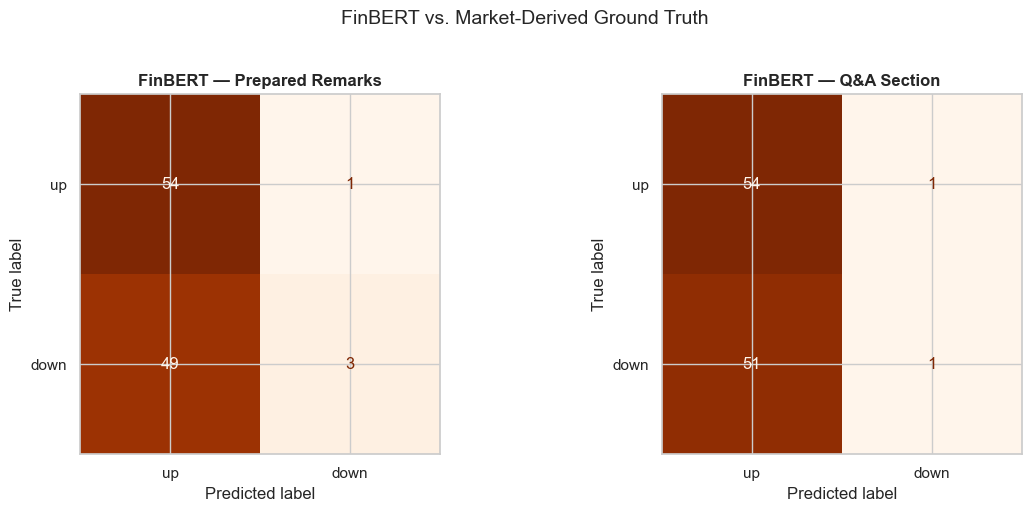

In [11]:
# FinBERT confusion matrix
eval_df = df[df['split_successful']].dropna(subset=['label_1d', 'pr_finbert_label'])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, pred_col, title in [
    (axes[0], 'pr_finbert_label', 'FinBERT — Prepared Remarks'),
    (axes[1], 'qa_finbert_label', 'FinBERT — Q&A Section'),
]:
    cm = confusion_matrix(eval_df['label_1d'], eval_df[pred_col], labels=labels)
    disp = ConfusionMatrixDisplay(cm, display_labels=labels)
    disp.plot(ax=ax, colorbar=False, cmap='Oranges')
    ax.set_title(title, fontsize=12, fontweight='bold')

plt.suptitle('FinBERT vs. Market-Derived Ground Truth', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 6. Evaluation — 4-Way Comparison
Compare all combinations of model × segment using accuracy, F1, and Pearson correlation.

In [12]:
# Full 4-way comparison table
from src.evaluation.metrics import compare_models

results_df = compare_models(df, ground_truth_col='label_1d')
display(results_df.set_index('condition').style.background_gradient(cmap='RdYlGn', subset=['macro_f1', 'pearson_r_1d']))

,n_samples,accuracy,macro_f1,weighted_f1,up_f1,down_f1,pearson_r_1d,pearson_p_1d,pearson_r_3d,pearson_p_3d
condition,,,,,,,,,,
PR_LM,107,0.467300,0.333100,0.341500,0.632300,0.033900,0.050400,0.605800,0.076500,0.456700
QA_LM,107,0.504700,0.433200,0.438800,0.634500,0.231900,-0.004600,0.962700,0.013000,0.899100
PR_FINBERT,107,0.532700,0.395300,0.403400,0.683500,0.107100,0.057800,0.554000,0.074700,0.467000
QA_FINBERT,107,0.514000,0.356000,0.365000,0.675000,0.037000,-0.112200,0.249900,-0.126500,0.216800


In [13]:
# F1 comparison bar chart
from src.evaluation.visualizations import plot_model_comparison_f1

plot_model_comparison_f1(
    results_df,
    output_path=Path('data/outputs/figures/model_comparison_f1.png')
)
plt.show()

INFO | Figure saved: data\outputs\figures\model_comparison_f1.png


In [14]:
# Pearson correlation heatmap
from src.evaluation.visualizations import plot_pearson_heatmap

plot_pearson_heatmap(
    results_df,
    output_path=Path('data/outputs/figures/pearson_heatmap.png')
)
plt.show()

INFO | Figure saved: data\outputs\figures\pearson_heatmap.png


INFO | Figure saved: data\outputs\figures\lm_pr_vs_returns.png


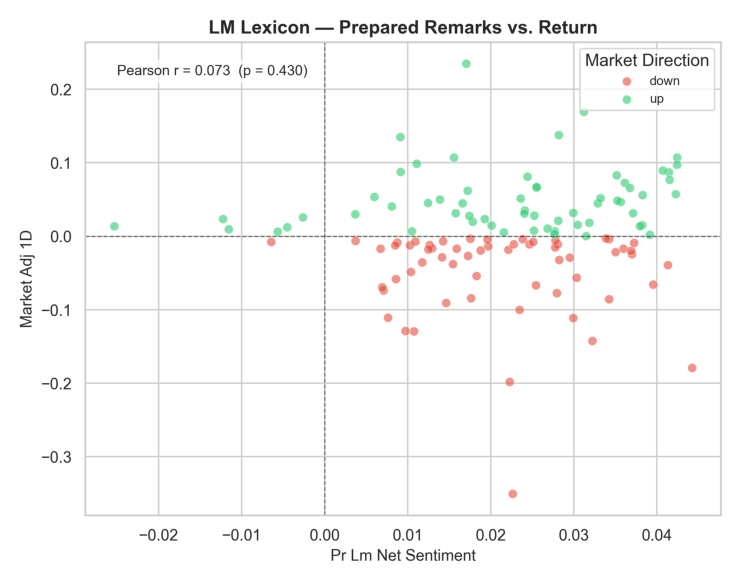

INFO | Figure saved: data\outputs\figures\lm_qa_vs_returns.png


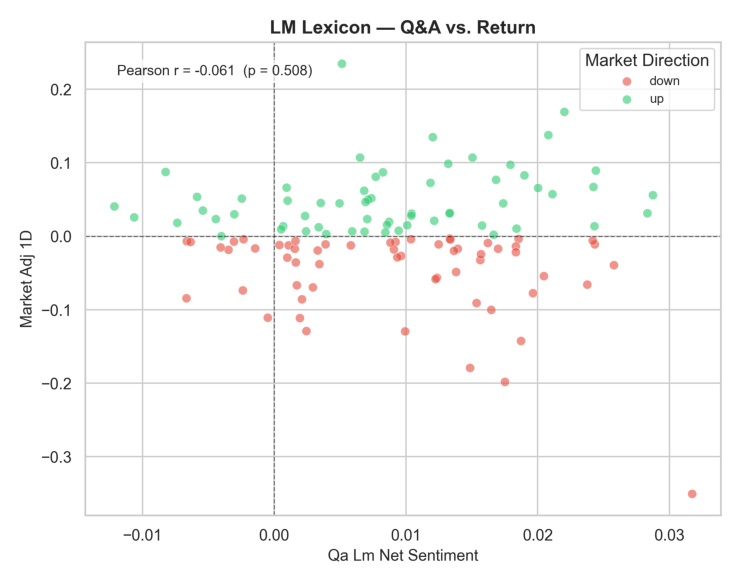

INFO | Figure saved: data\outputs\figures\finbert_pr_vs_returns.png


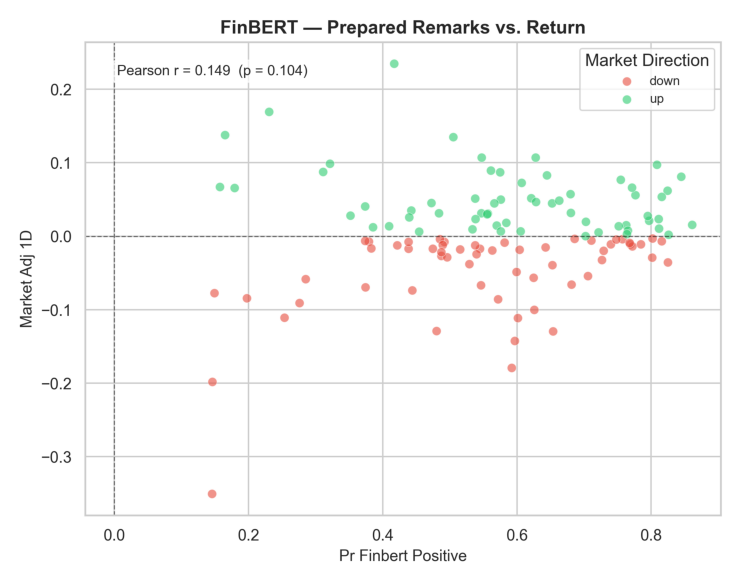

INFO | Figure saved: data\outputs\figures\finbert_qa_vs_returns.png


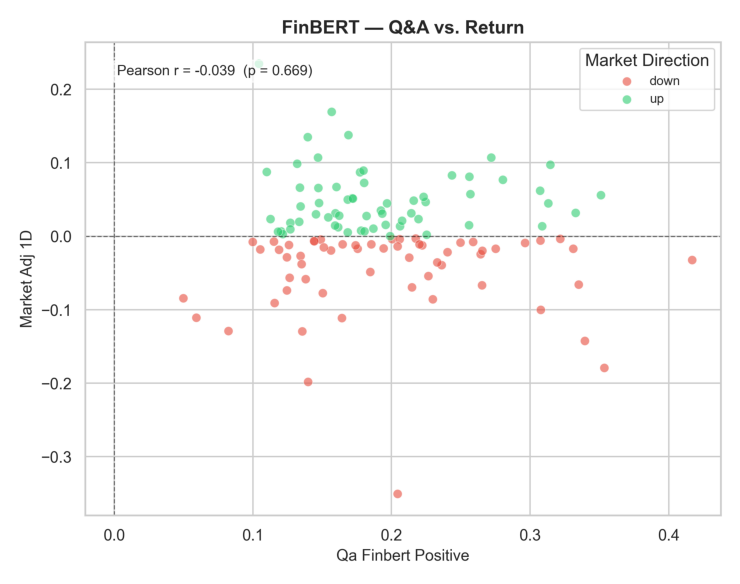

In [15]:
# Sentiment vs. returns scatter plots
from src.evaluation.visualizations import plot_sentiment_vs_returns

for score_col, title, fname in [
    ('pr_lm_net_sentiment', 'LM Lexicon — Prepared Remarks vs. Return', 'lm_pr_vs_returns.png'),
    ('qa_lm_net_sentiment', 'LM Lexicon — Q&A vs. Return', 'lm_qa_vs_returns.png'),
    ('pr_finbert_positive', 'FinBERT — Prepared Remarks vs. Return', 'finbert_pr_vs_returns.png'),
    ('qa_finbert_positive', 'FinBERT — Q&A vs. Return', 'finbert_qa_vs_returns.png'),
]:
    if score_col in df.columns:
        plot_sentiment_vs_returns(
            df, sentiment_col=score_col, title=title,
            output_path=Path(f'data/outputs/figures/{fname}')
        )
        img = plt.imread(f'data/outputs/figures/{fname}')
        fig, ax = plt.subplots(figsize=(8, 6))
        ax.imshow(img)
        ax.axis('off')
        plt.tight_layout()
        plt.show()

INFO | Figure saved: data\outputs\figures\sentiment_distribution.png


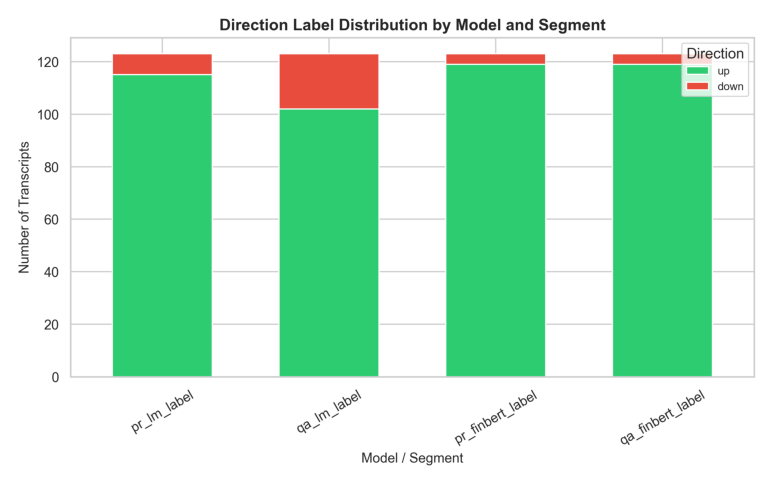

In [16]:
# Sentiment label distribution
from src.evaluation.visualizations import plot_sentiment_distribution

plot_sentiment_distribution(
    df,
    output_path=Path('data/outputs/figures/sentiment_distribution.png')
)
img = plt.imread('data/outputs/figures/sentiment_distribution.png')
fig, ax = plt.subplots(figsize=(10, 5))
ax.imshow(img)
ax.axis('off')
plt.tight_layout()
plt.show()

## 7. Error Analysis
Extract failure cases for manual inspection.  
Includes both sentiment mismatches and heuristic-split transcripts.

In [17]:
# Extract and display failure cases
from src.evaluation.error_analysis import export_failure_cases, extract_failure_cases

pred_col = 'pr_lm_label' if 'pr_lm_label' in df.columns else 'pr_finbert_label'
failures = extract_failure_cases(df, model_label_col=pred_col, min_cases=10)
export_failure_cases(failures, output_path=Path('data/outputs/failure_cases.csv'))

print(f'Total failure cases: {len(failures)}')
print()
print('Failure reason breakdown:')
print(failures['failure_reason'].value_counts())
print()
display(failures.head(10))

INFO | Failure cases: 57 mismatches + 13 heuristic splits = 70 total.
INFO | Failure cases exported to data\outputs\failure_cases.csv (70 rows).


Total failure cases: 70

Failure reason breakdown:
failure_reason
predicted_up_was_down    51
split_heuristic          13
predicted_down_was_up     6
Name: count, dtype: int64



,ticker,date,company,pr_lm_label,label_1d,market_adj_1d,failure_reason,split_method,prepared_excerpt,qa_excerpt
0,AMZN,2023-02-02,Amazon.com Inc.,up,down,-0.0737,predicted_up_was_down,regex_fallback,"Amazon.com ( AMZN +2.05% ) Q4 2022 Earnings Call Feb 02, 2023 , 5:30 p.m. ET...",Operator\nThank you. And the next question comes from the line of Doug Anmut...
1,AMZN,2023-04-27,Amazon.com Inc.,up,down,-0.0483,predicted_up_was_down,regex_fallback,"Amazon.com ( AMZN +2.05% ) Q1 2023 Earnings Call Apr 27, 2023 , 5:30 p.m. ET...","Operator\nThank you. At this time, we will now open the call for questions. ..."
2,BA,2022-01-26,Boeing Company,up,down,-0.0183,predicted_up_was_down,regex_fallback,"Boeing ( BA 1.10% ) Q4 2021 Earnings Call Jan 26, 2022 , 10:30 a.m. ET\nOper...",Operator\nCertainly. [Operator instructions] Our first question comes from S...
3,BA,2022-04-27,Boeing Company,up,down,-0.0268,predicted_up_was_down,regex_fallback,"Boeing ( BA 1.10% ) Q1 2022 Earnings Call Apr 27, 2022 , 10:30 a.m. ET\nOper...",Operator\n[Operator instructions] One moment for our first question. And tha...
4,BA,2023-01-25,Boeing Company,up,down,-0.0108,predicted_up_was_down,regex_fallback,"Boeing ( BA 1.10% ) Q4 2022 Earnings Call Jan 25, 2023 , 10:30 a.m. ET\nOper...",Operator\n[Operator instructions] Our first question will be from Peter Arme...
5,CRM,2023-05-31,Salesforce Inc.,up,down,-0.0564,predicted_up_was_down,regex_fallback,"Salesforce ( CRM 3.42% ) Q1 2024 Earnings Call May 31, 2023 , 5:00 p.m. ET\n...",Operator\n[Operator instructions] Your first question today comes from the l...
6,CVX,2022-01-28,Chevron Corporation,up,down,-0.0125,predicted_up_was_down,regex_fallback,"Chevron ( CVX 0.96% ) Q4 2021 Earnings Call Jan 28, 2022 , 11:00 a.m. ET\nOp...",Operator\nOur next question comes from Doug Leggate from Bank of America.\nD...
7,CVX,2022-04-29,Chevron Corporation,down,up,0.0136,predicted_down_was_up,regex_primary,"that are available on Chevron's website. Before we begin, please be reminded...","ed.\nKatie, please open the lines.\nOperator\nThank you. [Operator instructi..."
8,CVX,2022-07-29,Chevron Corporation,up,down,-0.0170,predicted_up_was_down,regex_fallback,"Chevron ( CVX 0.96% ) Q2 2022 Earnings Call Jul 29, 2022 , 11:00 a.m. ET\nOp...",Operator\nWe'll take our next question from Doug Leggate with Bank of Americ...
9,CVX,2022-10-28,Chevron Corporation,down,up,0.0123,predicted_down_was_up,regex_fallback,"Chevron ( CVX 0.96% ) Q3 2022 Earnings Call Oct 28, 2022 , 11:00 a.m. ET\nOp...",Operator\nOur next question will come from Roger Read with Wells Fargo.\nRog...


## 8. Discussion

### Key Findings
*(Fill in after running with live data)*

1. **Which segment predicts better?**  
   Preliminary expectation: Q&A sections may carry stronger predictive signal as analysts probe forward guidance, while Prepared Remarks are more rehearsed and PR-polished.

2. **Which model performs better?**  
   FinBERT should outperform the LM Lexicon for nuanced financial language (sarcasm, hedging), but the LM baseline may be competitive given the domain-specific vocabulary matching.

3. **Pearson Correlation Interpretation**  
   A Pearson r > 0.3 (p < 0.05) would indicate a meaningful linear relationship between sentiment scores and market returns, supporting the research hypothesis.

### Limitations
- Market returns are noisy proxies for sentiment correctness — macroeconomic events confound single-stock moves.
- The 3-8 second scraping delay and 124-transcript dataset may limit statistical power.
- FinBERT was pre-trained on older financial text and may not reflect post-2022 language patterns.
- With binary up/down labels, accuracy is a meaningful headline metric — but the macro-F1 split between up_F1 and down_F1 reveals that all models lean toward predicting "up" in this 2022-2023 sample.
